### Looking at esm1v sequence representations



Reference

```bibtex
@article{meier2021language,
  author = {Meier, Joshua and Rao, Roshan and Verkuil, Robert and Liu, Jason and Sercu, Tom and Rives, Alexander},
  title = {Language models enable zero-shot prediction of the effects of mutations on protein function},
  year={2021},
  doi={10.1101/2021.07.09.450648},
  url={https://www.biorxiv.org/content/10.1101/2021.07.09.450648v1},
  journal={bioRxiv}
}
```

In [25]:
import numpy as np
import pandas as pd
import scipy.stats

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns


import torch


In [9]:
seq_rep = torch.load("../cache/working/azid_sequence_representations.pt")
seq_rep = torch.stack(seq_rep) # stack into one tensor

In [10]:
model_seqs = pd.read_csv("../output/2D/azid_model_sequences.csv")

In [21]:
spearman_correlations = np.array([scipy.stats.spearmanr(model_seqs.response, seq_rep[:, i]).correlation
    for i in range(seq_rep.shape[1])])
kendalltau_correlations = np.array([scipy.stats.kendalltau(model_seqs.response, seq_rep[:, i]).correlation
    for i in range(seq_rep.shape[1])])

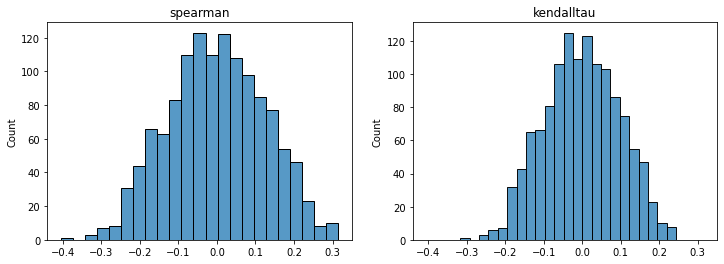

In [31]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), sharex=True)
ax = axs[0]
sns.histplot(spearman_correlations, ax=ax)
ax.set_title("spearman")
ax = axs[1]
sns.histplot(kendalltau_correlations, ax=axs[1])
ax.set_title("kendalltau")
pass